In [1]:
import numpy as np

In [8]:
pose =     np.load("/home/aadi_iiith/Desktop/IS/Tartan/MAC-VO/Results/MACVO-Fast@K00/11_01_095315/poses.npy")
ref_pose = np.load("/home/aadi_iiith/Desktop/IS/Tartan/MAC-VO/Results/MACVO-Fast@K00/11_01_095315/ref_poses.npy")

print(pose[:5])
print("REF")
print(ref_pose[:5])


[[ 0.00000000e+00 -3.72529030e-09  1.51339918e-09 -1.39698386e-09
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 1.03735900e+08  7.22008571e-03 -9.54631157e-03  7.19987333e-01
   2.89261341e-04  2.09406018e-03  8.04781914e-04  9.99997437e-01]
 [ 2.07338100e+08  1.65533870e-02 -1.97547134e-02  1.44099700e+00
   2.86340714e-04  3.92735004e-03  1.08110905e-03  9.99991655e-01]
 [ 3.11075200e+08  2.71067135e-02 -3.32905613e-02  2.16100502e+00
  -4.83527780e-04  5.60741127e-03  1.46384537e-03  9.99983072e-01]
 [ 4.14691700e+08  3.52082141e-02 -4.54036929e-02  2.88318610e+00
  -8.97109509e-04  7.37905502e-03  9.24348831e-04  9.99971867e-01]]
REF
[[ 0.00000000e+00 -9.99999972e-10 -0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 1.03735900e+08  9.19602811e-03  7.12104025e-04  6.82262361e-01
   4.75169742e-04  2.04930943e-03  7.90440768e-04  9.99997497e-01]
 [ 2.07338100e+08  1.82853416e-02  5.47608011e-04  1.36333966e+0

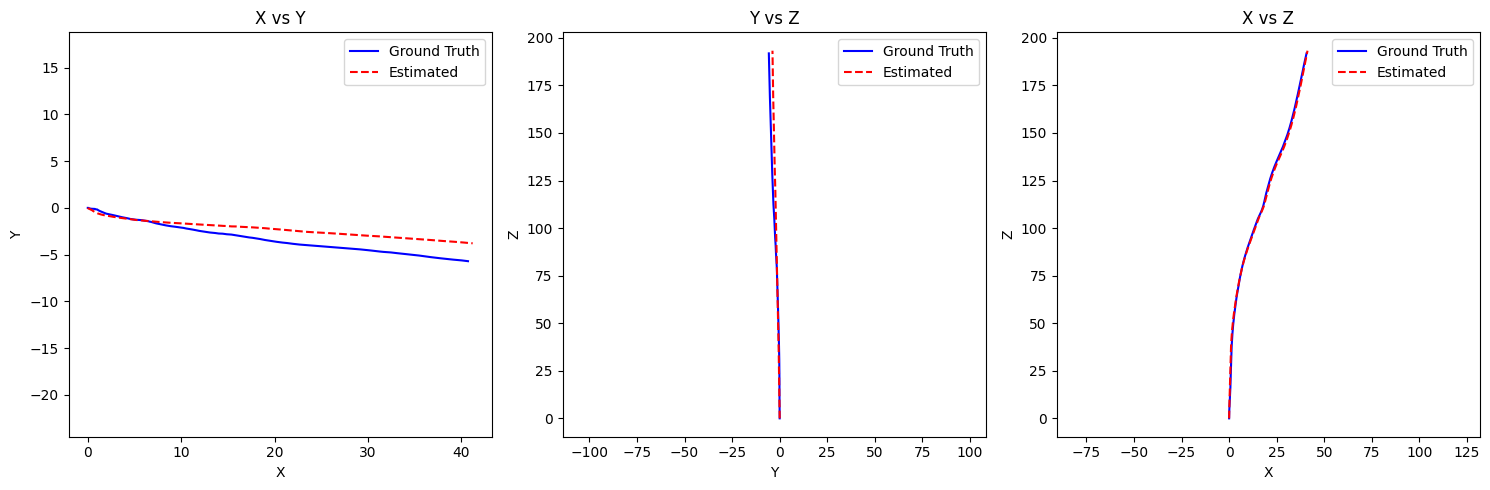

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Example: poses are Nx4x4 SE(3) matrices
# Replace these with your actual lists/arrays of poses
# gt_poses = [...]        # list of 4x4 ground truth matrices
# est_poses = [...]       # list of 4x4 estimated matrices

def extract_xyz(poses):
    """Extract x,y,z from list/array of 4x4 poses."""
    poses = np.array(poses)
    return poses[:, 1], poses[:, 2], poses[:,3]


# Extract trajectories
# p1 = np.load("/home/aadi_iiith/Desktop/IS/Tartan/MAC-VO/Results/MACVO-Fast@K00/10_31_205027/poses.npy")
# p2 = np.load("/home/aadi_iiith/Desktop/IS/Tartan/MAC-VO/Results/MACVO-Fast@K00/10_31_205814/poses.npy")
# print(p1[0])
# print(p2[0])
# print(p1[2])

gt_x, gt_y, gt_z = extract_xyz(ref_pose)
est_x, est_y, est_z = extract_xyz(pose)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# X vs Y
axes[0].plot(gt_x, gt_y, 'b-', label="Ground Truth")
axes[0].plot(est_x, est_y, 'r--', label="Estimated")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title("X vs Y")
axes[0].legend()
axes[0].axis("equal")

# Y vs Z
axes[1].plot(gt_y, gt_z, 'b-', label="Ground Truth")
axes[1].plot(est_y, est_z, 'r--', label="Estimated")
axes[1].set_xlabel("Y")
axes[1].set_ylabel("Z")
axes[1].set_title("Y vs Z")
axes[1].legend()
axes[1].axis("equal")

# X vs Z
axes[2].plot(gt_x, gt_z, 'b-', label="Ground Truth")
axes[2].plot(est_x, est_z, 'r--', label="Estimated")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Z")
axes[2].set_title("X vs Z")
axes[2].legend()
axes[2].axis("equal")

plt.tight_layout()
plt.show()


In [10]:
i = 2
print(ref_pose[i])
print(    pose[i])
import numpy as np
from scipy.spatial.transform import Rotation as R

def quat_to_se3(q, t):
    """
    q: (4,) quaternion in (qw, qx, qy, qz) format
    t: (3,) translation (tx, ty, tz)
    returns: (4,4) SE(3) transform matrix
    """
    r = R.from_quat([q[0], q[1], q[2], q[3]])  # scipy uses (x,y,z,w)
    R_mat = r.as_matrix()

    T = np.eye(4)
    T[:3, :3] = R_mat
    T[:3, 3]  = t
    return T

# Example:
# q = [0.9239, 0.3827, 0, 0]  # (qw,qx,qy,qz)
# t = [1, 2, 3]
# T = quat_to_se3(q, t)
# print(T)


[2.07338100e+08 1.82853416e-02 5.47608011e-04 1.36333966e+00
 5.57108724e-04 3.87134613e-03 1.26478565e-03 9.99991596e-01]
[ 2.07338100e+08  1.65533870e-02 -1.97547134e-02  1.44099700e+00
  2.86340714e-04  3.92735004e-03  1.08110905e-03  9.99991655e-01]


In [11]:
import numpy as np

def make_SE3(R, T):
    T = np.array(T).reshape(3)
    SE3 = np.eye(4)
    SE3[:3, :3] = np.array(R).reshape(3,3)
    SE3[:3, 3] = T
    return SE3


# ---- IMU → Velodyne ----
R_imu_to_velo = [
    9.999976e-01, 7.553071e-04, -2.035826e-03,
    -7.854027e-04, 9.998898e-01, -1.482298e-02,
    2.024406e-03, 1.482454e-02, 9.998881e-01
]
T_imu_to_velo = [-8.086759e-01, 3.195559e-01, -7.997231e-01]
T_imu_velo = make_SE3(R_imu_to_velo, T_imu_to_velo)


# ---- Velodyne → Camera ----
R_velo_to_cam = [
    7.533745e-03, -9.999714e-01, -6.166020e-04,
    1.480249e-02, 7.280733e-04, -9.998902e-01,
    9.998621e-01, 7.523790e-03, 1.480755e-02
]
T_velo_to_cam = [-4.069766e-03, -7.631618e-02, -2.717806e-01]
T_velo_cam = make_SE3(R_velo_to_cam, T_velo_to_cam)


# ---- Rectification ----
R_rect_00 = [
    9.999239e-01, 9.837760e-03, -7.445048e-03,
    -9.869795e-03, 9.999421e-01, -4.278459e-03,
    7.402527e-03, 4.351614e-03, 9.999631e-01
]
T_rect = np.eye(4)
T_rect[:3,:3] = np.array(R_rect_00).reshape(3,3)


# ---- Full IMU → Camera-Rect SE(3) ----
T_imu_to_camrect = np.linalg.inv(T_rect @ T_velo_cam @ T_imu_velo)  # 4x4


# ---- Convert a pose or batch of poses ----
def imu_pose_to_cam_pose(SE3_imu):
    """
    SE3_imu: either (4,4) or (N,4,4)
    Returns same shape in camera-rect frame.
    """
    if SE3_imu.ndim == 2:          # (4,4)
        return SE3_imu @ T_imu_to_camrect

    elif SE3_imu.ndim == 3:        # (N,4,4)
        return np.einsum('ij,njk->nik', SE3_imu, T_imu_to_camrect)

    else:
        raise ValueError("SE3 must be (4,4) or (N,4,4)")
T_orig = quat_to_se3(ref_pose[0][4:],ref_pose[0][1:4])
T_cam_orig = T_imu_to_camrect @ T_orig

T_ref = quat_to_se3(ref_pose[i][4:],ref_pose[i][1:4])
T_pose = quat_to_se3(pose[i][4:],pose[i][1:4])
print("REF",T_ref)
print("POSE",T_pose)
T_cam = T_imu_to_camrect @ T_ref
T_cam = np.linalg.inv(T_cam_orig) @ T_cam
print("CAM",T_cam)
print(T_imu_to_camrect)

REF [[ 9.99966826e-01 -2.52523629e-03  7.74403574e-03  1.82853416e-02]
 [ 2.53386334e-03  9.99996180e-01 -1.10441514e-03  5.47608011e-04]
 [-7.74121724e-03  1.12400083e-03  9.99969405e-01  1.36333966e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
POSE [[ 9.99966814e-01 -2.15995096e-03  7.85525379e-03  1.65533870e-02]
 [ 2.16444920e-03  9.99997498e-01 -5.64184869e-04 -1.97547134e-02]
 [-7.85401553e-03  5.81168444e-04  9.99968988e-01  1.44099700e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
CAM [[ 9.99966826e-01 -2.52523629e-03  7.74403574e-03  1.82853426e-02]
 [ 2.53386334e-03  9.99996180e-01 -1.10441514e-03  5.47608011e-04]
 [-7.74121724e-03  1.12400083e-03  9.99969405e-01  1.36333966e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[ 9.98747016e-04  8.41690127e-03  9.99964108e-01  1.08330198e+00]
 [-9.99990478e-01 -4.25082354e-03  1.03455365e-03 -3.09888901e-01]
 [ 4.25937626e-03 -9.99955515e-01  8.41257580e

In [6]:
T_orig_imu = quat_to_se3(ref_pose[0][4:], ref_pose[0][1:4]) # T_world_imu (at i=0)
T_ref_imu = quat_to_se3(ref_pose[i][4:], ref_pose[i][1:4])  # T_world_imu (at i=i)

# 1. Transform absolute IMU poses to absolute Camera poses
T_orig_cam = T_orig_imu @ T_imu_to_camrect  # RIGHT-multiply
T_ref_cam = T_ref_imu @ T_imu_to_camrect    # RIGHT-multiply

# 2. Now, create the relative pose *from the camera-frame poses*
# This aligns the trajectory to start at the origin (identity)
T_cam_relative = np.linalg.inv(T_orig_cam) @ T_ref_cam

# T_cam_relative is now the correct GT to compare against your prediction
print("REF (Absolute IMU Pose):\n", T_ref_imu)
print("POSE (Prediction):\n", T_pose)
print("CAM (Corrected Relative Camera GT):\n", T_cam_relative)

REF (Absolute IMU Pose):
 [[ 9.99969574e-01  7.71477089e-03 -1.15450781e-03  1.36658001e+00]
 [-7.71774174e-03  9.99966860e-01 -2.59132500e-03 -6.63521420e-03]
 [ 1.13447807e-03  2.60015635e-03  9.99995976e-01  1.05792126e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
POSE (Prediction):
 [[ 9.99966779e-01 -2.17209056e-03  7.85635182e-03  1.64552927e-02]
 [ 2.17674721e-03  9.99997460e-01 -5.84222299e-04 -1.98704023e-02]
 [-7.85506288e-03  6.01304182e-04  9.99968968e-01  1.43881357e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
CAM (Corrected Relative Camera GT):
 [[ 9.99966826e-01 -2.52523609e-03  7.74403550e-03  1.82853442e-02]
 [ 2.53386352e-03  9.99996180e-01 -1.10441526e-03  5.47608845e-04]
 [-7.74121729e-03  1.12400080e-03  9.99969405e-01  1.36333969e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


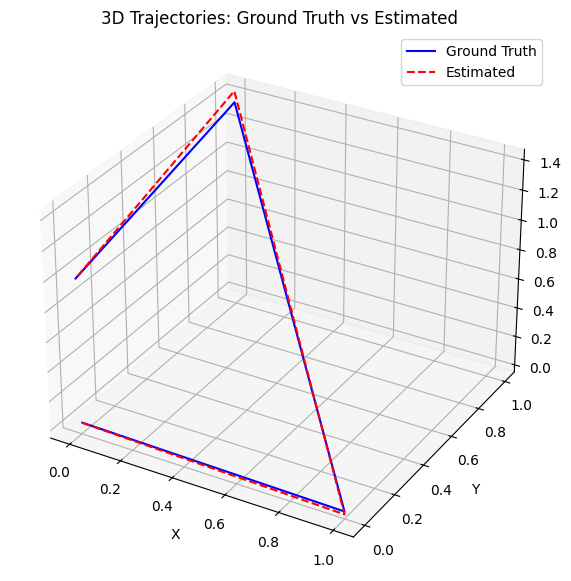

In [7]:
gt_x, gt_y, gt_z = extract_xyz(T_cam_relative)
est_x, est_y, est_z = extract_xyz(T_pose)

# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Ground Truth and Estimated poses in 3D
ax.plot(gt_x, gt_y, gt_z, 'b-', label="Ground Truth")
ax.plot(est_x, est_y, est_z, 'r--', label="Estimated")

# Labels and Title
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Trajectories: Ground Truth vs Estimated")
ax.legend()

plt.show()